In [1]:
import os
import sys
import pandas as pd
import yaml 
from matplotlib import pyplot as plt
from matplotlib import ticker as mticker
from matplotlib import colors as mcolors
from matplotlib import patches as mpatches
import statsmodels.api as sm
import numpy as np
from itertools import product
import subprocess

plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 11
#plt.rcParams['text.usetex'] = True

from sklearn.decomposition import PCA

with open("../../config.yaml.local", "r") as f:
    LOCAL_CONFIG = yaml.safe_load(f)
with open("../../config.yaml", "r") as f:
    CONFIG = yaml.safe_load(f)
sys.path.append("../python")

import globals
import data_tools as dt
import writing_tools as wt
import utils
import emb
from utils import weighted_kreg

LOCAL_PATH = LOCAL_CONFIG["LOCAL_PATH"]
RAW_DATA_PATH = LOCAL_CONFIG["RAW_DATA_PATH"]
DATA_PATH = LOCAL_CONFIG["DATA_PATH"]
R_PATH = LOCAL_CONFIG["R_PATH"]

RUN_R_SCRIPTS = False
REPLACE_ANALYSIS_DATA = False

TITLE_PCA_K = 10
TEXT_PCA_K = 10

rng = np.random.default_rng(42)


In [2]:
# Making analysis data for R

df = dt.get_post_quality_analysis_data()
df = df.loc[df['title'] != 'deleted by author'].reset_index(drop=True)

emb_df = pd.read_parquet(os.path.join(DATA_PATH, "post_embeddings_pca.parquet"))

df = df.merge(emb_df, on="itemId", how="inner")

df.to_parquet(os.path.join(DATA_PATH, "v4v-analysis-2.parquet"), index=False)


/Users/ekung/projects/sn-research/src/notebooks/../python/data_tools.py:89: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  return x.dt.to_period('W-SAT').dt.start_time
/Users/ekung/projects/sn-research/src/notebooks/../python/data_tools.py:89: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  return x.dt.to_period('W-SAT').dt.start_time


In [3]:
# Running initial R regression to get quality measures

res = subprocess.run([R_PATH, LOCAL_PATH + "/src/R/04_v4v_analysis.R"], check=True, capture_output=True, text=True)
print(res.stdout)

                                 r1                 r2                  r3
Dependent Var.:          log_sats48         log_sats48          log_sats48
                                                                          
Constant          3.124*** (0.4029)  3.380*** (0.4611)                    
log_numwords     0.3536*** (0.0535)  0.2663** (0.0855)  0.1404*** (0.0332)
no_textTRUE         0.1927 (0.2545)   -0.3781 (0.2951)     0.0197 (0.0966)
is_link_postTRUE  -0.5310* (0.2392)  -0.2108* (0.0978) -0.4675*** (0.0376)
num_img_or_links   0.0192. (0.0114)   0.0138* (0.0062)    0.0090. (0.0051)
text_emb_0                             0.5476 (0.4882)   -0.2673. (0.1367)
text_emb_1                            -0.2226 (0.3705)   0.4779** (0.1791)
text_emb_2                             0.5711 (0.7226)   -0.4402. (0.2632)
text_emb_3                             0.3061 (0.5047)    -0.1204 (0.1273)
text_emb_4                          -3.138*** (0.4244)  -1.930*** (0.1984)
text_emb_5               

In [4]:
# Zaps regression table

coefs_df = pd.read_parquet(os.path.join(DATA_PATH, "v4v-analysis-2-zreg.parquet"))

header = r"""\begin{table}[H]
\centering
\caption{Regression of Post Zaps on Post Attributes} \label{tbl_v4v_zreg}
\begin{threeparttable}
\begin{tabular}{@{\extracolsep{5pt}}lccc} 
\\[-1.8ex]\hline 
\hline \\[-1.8ex] 
 & \multicolumn{3}{c}{\textit{Dependent variable:}} \\ 
\cline{2-4} 
\\[-1.8ex] & \multicolumn{3}{c}{log(Zaps)} \\ 
\\[-1.8ex] & (1) & (2) & (3) \\ 
\hline \\[-1.8ex] 
"""
footer = r"""\end{tabular} 
\begin{tablenotes}[flushleft]\footnotesize
\item[] \parbox[t]{\linewidth}{%
\hfill * $p<0.1$, ** $p<0.05$, *** $p<0.01$.
}
\item \textit{Notes:} Regression of number of sats a post earns in the first 48 hours on post attributes. The unit of observation is a post. Standard errors are clustered by territory.
\end{tablenotes}
\end{threeparttable}
\end{table}
"""
reg_names = ["r1", "r2", "r3"]

vars = [
    ("log_numwords", "log(\\# Words)"),
    ("no_textTRUE", "No text"),
    ("is_link_postTRUE", "Is link post"),
    ("num_img_or_links", "\\# Images and links in post body"),
    ("(Intercept)", "Constant"),
]

tbl = ""
for v in vars:
    tbl += v[1] + " "
    for rn in reg_names:
        idx = (coefs_df["regression_name"]==rn) & (coefs_df["coef_name"]==v[0])
        if idx.sum()==0:
            tbl += " & "
            continue
        coef = coefs_df.loc[idx, "estimate"].values[0]
        serr = coefs_df.loc[idx, "serr"].values[0]
        stars = utils.stars(coef, serr)
        tbl += f" & {coef:.3f}$^{{{stars}}}$"
    tbl += r" \\" + "\n"
    for rn in reg_names:
        idx = (coefs_df["regression_name"]==rn) & (coefs_df["coef_name"]==v[0])
        if idx.sum()==0:
            tbl += " & "
            continue
        serr = coefs_df.loc[idx, "serr"].values[0]
        tbl += f" & ({serr:.3f})"
    tbl += r" \\" + "\n"

tbl += r"""& & & \\
\hline \\ [-1.8ex]
Text Embeddings         & N & Y & Y \\
Territory FE            & N & N & Y \\
User FE                 & N & N & Y \\
"""

tbl += "Observations "
for rn in reg_names:
    idx = (coefs_df["regression_name"]==rn) & (coefs_df["coef_name"]=="num_obs")
    nobs = coefs_df.loc[idx, "estimate"].values[0]
    tbl += f" & {nobs:,.0f}"
tbl += r" \\" + "\n"

tbl += "$R^2$ "
for rn in reg_names:
    idx = (coefs_df["regression_name"]==rn) & (coefs_df["coef_name"]=="R2")
    r2 = coefs_df.loc[idx, "estimate"].values[0]
    tbl += f" & {r2:.3f}"
tbl += r" \\ \hline \hline " + "\n"

table_tex = header + tbl + footer    

with open(os.path.join(LOCAL_PATH, "results", "tbl_v4v_zreg.tex"), "w") as f:
    f.write(table_tex)

print(table_tex)

\begin{table}[H]
\centering
\caption{Regression of Post Zaps on Post Attributes} \label{tbl_v4v_zreg}
\begin{threeparttable}
\begin{tabular}{@{\extracolsep{5pt}}lccc} 
\\[-1.8ex]\hline 
\hline \\[-1.8ex] 
 & \multicolumn{3}{c}{\textit{Dependent variable:}} \\ 
\cline{2-4} 
\\[-1.8ex] & \multicolumn{3}{c}{log(Zaps)} \\ 
\\[-1.8ex] & (1) & (2) & (3) \\ 
\hline \\[-1.8ex] 
log(\# Words)  & 0.354$^{***}$ & 0.266$^{***}$ & 0.140$^{***}$ \\
 & (0.054) & (0.085) & (0.033) \\
No text  & 0.193$^{}$ & -0.378$^{}$ & 0.020$^{}$ \\
 & (0.255) & (0.295) & (0.097) \\
Is link post  & -0.531$^{**}$ & -0.211$^{**}$ & -0.467$^{***}$ \\
 & (0.239) & (0.098) & (0.038) \\
\# Images and links in post body  & 0.019$^{*}$ & 0.014$^{**}$ & 0.009$^{*}$ \\
 & (0.011) & (0.006) & (0.005) \\
Constant  & 3.124$^{***}$ & 3.380$^{***}$ &  \\
 & (0.403) & (0.461) &  \\
& & & \\
\hline \\ [-1.8ex]
Text Embeddings         & N & Y & Y \\
Territory FE            & N & N & Y \\
User FE                 & N & N & Y \\
Observa

In [5]:
# Explore most important embedding dimensions

important_dims = []
for k in range(10):
    est = coefs_df.loc[(coefs_df["regression_name"]=="r3") & (coefs_df["coef_name"]==f"text_emb_{k}"), "estimate"].values[0]
    serr = coefs_df.loc[(coefs_df["regression_name"]=="r3") & (coefs_df["coef_name"]==f"text_emb_{k}"), "serr"].values[0]
    stars = utils.stars(est, serr)
    if stars!="":
        important_dims.append({"coef_name": f"text_emb_{k}", "estimate": est})
important_dims = pd.DataFrame(important_dims)
important_dims = important_dims.sort_values(by="estimate", key=abs, ascending=False).reset_index(drop=True)


In [6]:
for i in range(3):
    my_coef = important_dims.loc[i, "coef_name"]
    my_est = important_dims.loc[i, "estimate"]
    df["sort_key"] = df[my_coef] * my_est
    print("*************************************************************************")
    print(my_coef)
    print("")
    print("--------------------------------------------------------")
    print("HIGH CONTRIBUTION EXAMPLES")
    for _, row in df.sort_values(by="sort_key", ascending=False).head(3).iterrows():
        print("--------------------------------------------------------")
        print(f"**{row['title']}**")
        print("")
        print(row["text"][0:300].replace("\n", " "))
        print("")
    print("--------------------------------------------------------")
    print("LOW CONTRIBUTION EXAMPLES")
    for _, row in df.sort_values(by="sort_key", ascending=True).head(3).iterrows():
        print("--------------------------------------------------------")
        print(f"**{row['title']}**")
        print("")
        print(row["text"][0:400].replace("\n", " "))
        print("")

*************************************************************************
text_emb_4

--------------------------------------------------------
HIGH CONTRIBUTION EXAMPLES
--------------------------------------------------------
**Joy of Stacking Sats on SN**

49 days of being with the cowboy hat. This is written in anticipation that I will make it to my 50th.  50 is a nice round number. Half of a hundred. The passing grade on exams. While I know I have a long way to go, it reminds me of how far I have come.  First, some paradoxical advice. Don’t center “

--------------------------------------------------------
**Ideal Posting Mentality on Stacker News**

I asked before about [your posting routine](https://stacker.news/items/499454).  I gave suggestions about [what and where you could comment on Stacker News.](https://stacker.news/items/430155)  I wrote about [10 reasons why you should post on SN.](https://stacker.news/items/415525)  But I think I’m 

-----------------------------------

In [7]:
# pca explanations

text = r"After running regression \eqref{eq_zreg}, we inspected the embedding dimensions that were most predictive of zaps. The first most predictive dimension appears to capture meta-posts (not necessarily in the \texttt{meta} territory) about Stacker News itself, such as tips for how to post and earn more sats. The second most predictive dimension appears to capture posts about geopolitical and macroeconomic events, such as a personal discussion about elections in Venezuela. The third most predictive dimension appears to capture posts that ask questions about personal finance."
with open(os.path.join(LOCAL_PATH, "results", "pca_explanations.tex"), "w") as f:
    f.write(text)

In [8]:
# Learning regression table

coefs_df = pd.read_parquet(os.path.join(DATA_PATH, "v4v-analysis-2-qreg.parquet"))

header = r"""\begin{table}[H]
\centering
\caption{Regression of Next Post Quality on Past Zap Surprises} \label{tbl_v4v_qreg}
\begin{threeparttable}
\begin{tabular}{@{\extracolsep{5pt}}lccc} 
\\[-1.8ex]\hline 
\hline \\[-1.8ex] 
 & \multicolumn{3}{c}{\textit{Dependent variable:}} \\ 
\cline{2-4} 
\\[-1.8ex] & \multicolumn{3}{c}{Quality of next post ($q_{i,k+1}$)} \\ 
\\[-1.8ex] & (1) & (2) & (3) \\ 
\hline \\[-1.8ex] 
"""
footer = r"""\end{tabular} 
\begin{tablenotes}[flushleft]\footnotesize
\item[] \parbox[t]{\linewidth}{%
\hfill * $p<0.1$, ** $p<0.05$, *** $p<0.01$.
}
\item \textit{Notes:} Regression of next post quality ($q_{i,k+1}$) on the average of prior zap surprises ($\hat{\theta}_{ik} = \frac{1}{k} \sum_{j=1}^{k} \ln z_j - q_j$). The unit of observation is a post. Standard errors are clustered by territory.
\end{tablenotes}
\end{threeparttable}
\end{table}
"""
reg_names = ["r4", "r5", "r6"]

vars = [
    ("avg_surprise", r"Avg of past zap surprises ($\hat{\theta}_{ik}$)"),
    ("log_prior_zaps", "log(Total prior zaps)"),
    ("log_prior_posts", "log(Total prior posts)")
]

tbl = ""
for v in vars:
    tbl += v[1] + " "
    for rn in reg_names:
        idx = (coefs_df["regression_name"]==rn) & (coefs_df["coef_name"]==v[0])
        if idx.sum()==0:
            tbl += " & "
            continue
        coef = coefs_df.loc[idx, "estimate"].values[0]
        serr = coefs_df.loc[idx, "serr"].values[0]
        stars = utils.stars(coef, serr)
        tbl += f" & {coef:.3f}$^{{{stars}}}$"
    tbl += r" \\" + "\n"
    for rn in reg_names:
        idx = (coefs_df["regression_name"]==rn) & (coefs_df["coef_name"]==v[0])
        if idx.sum()==0:
            tbl += " & "
            continue
        serr = coefs_df.loc[idx, "serr"].values[0]
        tbl += f" & ({serr:.3f})"
    tbl += r" \\" + "\n"

tbl += r"""& & & \\
\hline \\ [-1.8ex]
Territory FE            & Y & Y & Y \\
User FE                 & Y & Y & Y \\
Week FE                 & N & N & Y \\
"""

tbl += "Observations "
for rn in reg_names:
    idx = (coefs_df["regression_name"]==rn) & (coefs_df["coef_name"]=="num_obs")
    nobs = coefs_df.loc[idx, "estimate"].values[0]
    tbl += f" & {nobs:,.0f}"
tbl += r" \\ \hline \hline " + "\n"

table_tex = header + tbl + footer    

with open(os.path.join(LOCAL_PATH, "results", "tbl_v4v_qreg.tex"), "w") as f:
    f.write(table_tex)

print(table_tex)

\begin{table}[H]
\centering
\caption{Regression of Next Post Quality on Past Zap Surprises} \label{tbl_v4v_qreg}
\begin{threeparttable}
\begin{tabular}{@{\extracolsep{5pt}}lccc} 
\\[-1.8ex]\hline 
\hline \\[-1.8ex] 
 & \multicolumn{3}{c}{\textit{Dependent variable:}} \\ 
\cline{2-4} 
\\[-1.8ex] & \multicolumn{3}{c}{Quality of next post ($q_{i,k+1}$)} \\ 
\\[-1.8ex] & (1) & (2) & (3) \\ 
\hline \\[-1.8ex] 
Avg of past zap surprises ($\hat{\theta}_{ik}$)  & 0.112$^{***}$ & 0.060$^{***}$ & 0.042$^{***}$ \\
 & (0.011) & (0.013) & (0.006) \\
log(Total prior zaps)  &  & 0.077$^{***}$ & -0.008$^{***}$ \\
 &  & (0.007) & (0.002) \\
log(Total prior posts)  &  & 0.000$^{***}$ & 0.000$^{***}$ \\
 &  & (0.000) & (0.000) \\
& & & \\
\hline \\ [-1.8ex]
Territory FE            & Y & Y & Y \\
User FE                 & Y & Y & Y \\
Week FE                 & N & N & Y \\
Observations  & 170,936 & 170,936 & 170,936 \\ \hline \hline 
\end{tabular} 
\begin{tablenotes}[flushleft]\footnotesize
\item[] \parbo

In [9]:
# v4v results

coefs_df = pd.read_parquet(os.path.join(DATA_PATH, "v4v-analysis-2-qreg.parquet"))

idx = (coefs_df["regression_name"]=="r6") & (coefs_df["coef_name"]=="avg_surprise")
coef = coefs_df.loc[idx, "estimate"].values[0]
elast = f"{coef:.3f}"
double_effect = np.exp(coef*np.log(2)) - 1
double_effect_pct = fr"{np.abs(double_effect)*100:.1f}"

RESULTS = {
    'LearningElasticity': elast,
    'LearningDoublingEffect': double_effect_pct
}
_ = wt.update_results(RESULTS)
RESULTS


{'LearningElasticity': '0.042', 'LearningDoublingEffect': '2.9'}

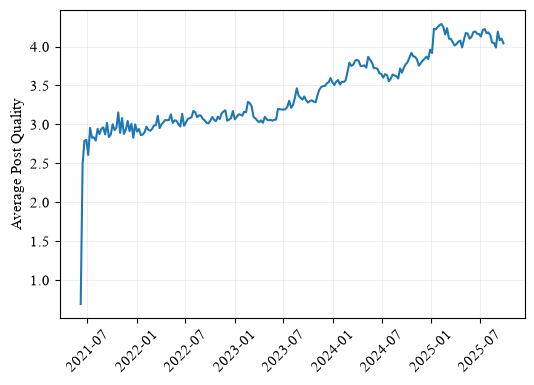

In [10]:
# Graph of post quality over time

df = pd.read_parquet(os.path.join(DATA_PATH, "v4v-analysis-2-data-w-q.parquet"))

plot_df = df.groupby('week').agg(
    q = ('q', 'mean')
).reset_index()

plt.figure(figsize=(6, 4))
plt.plot(plot_df['week'], plot_df['q'])
plt.xticks(rotation=45)
plt.grid(alpha=0.2)
plt.ylabel('Average Post Quality')
plt.savefig(os.path.join(LOCAL_PATH, "results", "fig_v4v_q_trend.pdf"), bbox_inches='tight')
plt.show()

tex = r"""
\begin{figure}[H]
\caption{Post Quality Over Time} \label{fig_v4v_q_trend}
\vspace{-0.8cm}
\begin{center}
\begin{adjustbox}{width=\textwidth}
\includegraphics{results/fig_v4v_q_trend.pdf}
\end{adjustbox}
\end{center}
\vspace{-0.5cm}
\footnotesize \textit{Note:} Shows the average post quality as measured by objective post attributes ($q_{ij}$) for each week. See Section \ref{sec_v4v} for details. 
\end{figure}
"""
with open(os.path.join(LOCAL_PATH, "results", "fig_v4v_q_trend.tex"), "w") as f:
    f.write(tex)


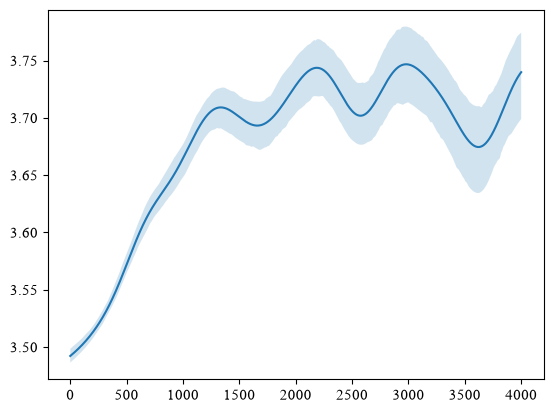

In [12]:
# Post quality vs experience

df = df.sort_values(by=['userId', 'itemId'], ascending=True).reset_index(drop=True)
df['cum_posts'] = df.groupby('userId')['itemId'].cumcount() + 1
df['ones'] = 1

grid = np.linspace(0, 4000, 1000)
bw = 200
nboot = 0
y_pred, ci_lower, ci_upper = weighted_kreg(
    df['cum_posts'].to_numpy(float), 
    df['q'].to_numpy(float), 
    df['ones'].to_numpy(float),
    bw,
    grid
)

plt.plot(grid, y_pred)
plt.fill_between(grid, ci_lower, ci_upper, alpha=0.2)




In [ ]:
y_pred

array([3.47755616, 3.47824865, 3.47895782, 3.47968393, 3.48042725,
       3.48118801, 3.48196644, 3.48276275, 3.48357712, 3.48440969,
       3.4852606 , 3.48612995, 3.48701778, 3.48792412, 3.48884895,
       3.4897922 , 3.49075374, 3.49173342, 3.492731  , 3.49374619,
       3.49477863, 3.49582791, 3.49689352, 3.49797489, 3.49907136,
       3.50018221, 3.50130662, 3.50244366, 3.50359235, 3.50475159,
       3.50592021, 3.50709692, 3.50828038, 3.50946912, 3.51066162,
       3.51185626, 3.51305134, 3.51424511, 3.51543574, 3.51662136,
       3.51780005, 3.51896987, 3.52012884, 3.521275  , 3.5224064 ,
       3.5235211 , 3.52461721, 3.52569292, 3.52674648, 3.52777624,
       3.52878067, 3.52975836, 3.53070807, 3.5316287 , 3.53251935,
       3.53337929, 3.53420801, 3.53500521, 3.53577081, 3.53650494,
       3.53720797, 3.53788049, 3.53852332, 3.53913749, 3.53972424,
       3.54028501, 3.54082145, 3.54133535, 3.54182867, 3.54230354,
       3.54276219, 3.54320694, 3.54364024, 3.54406457, 3.54448